Parsed 250 epoch-loss pairs from ./scaling_r0.99_s1.log
Parsed 250 epoch-loss pairs from ./scaling_r0.99_s2.log
Parsed 250 epoch-loss pairs from ./scaling_r0.99_s3.log
Parsed 250 epoch-loss pairs from ./scaling_r0.99_s4.log
Parsed 250 epoch-loss pairs from ./scaling_r0.99_s5.log
Parsed 250 epoch-loss pairs from ./scaling_r0.5_s1.log
Parsed 250 epoch-loss pairs from ./scaling_r0.5_s2.log
Parsed 250 epoch-loss pairs from ./scaling_r0.5_s3.log
Parsed 250 epoch-loss pairs from ./scaling_r0.5_s4.log
Parsed 250 epoch-loss pairs from ./scaling_r0.5_s5.log
Parsed 250 epoch-loss pairs from ./scaling_r0.25_s1.log
Parsed 250 epoch-loss pairs from ./scaling_r0.25_s2.log
Parsed 250 epoch-loss pairs from ./scaling_r0.25_s3.log
Parsed 250 epoch-loss pairs from ./scaling_r0.25_s4.log
Parsed 250 epoch-loss pairs from ./scaling_r0.25_s5.log
Parsed 250 epoch-loss pairs from ./scaling_r0.125_s1.log
Parsed 250 epoch-loss pairs from ./scaling_r0.125_s2.log
Parsed 250 epoch-loss pairs from ./scaling_r0.125_s

/tmp/ipykernel_659710/380266565.py:85: RuntimeWarning: invalid value encountered in log
  return a * np.log(b * np.log(c * x + d) + e) + f


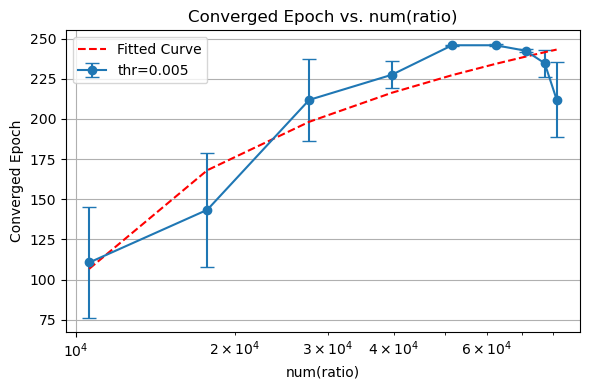

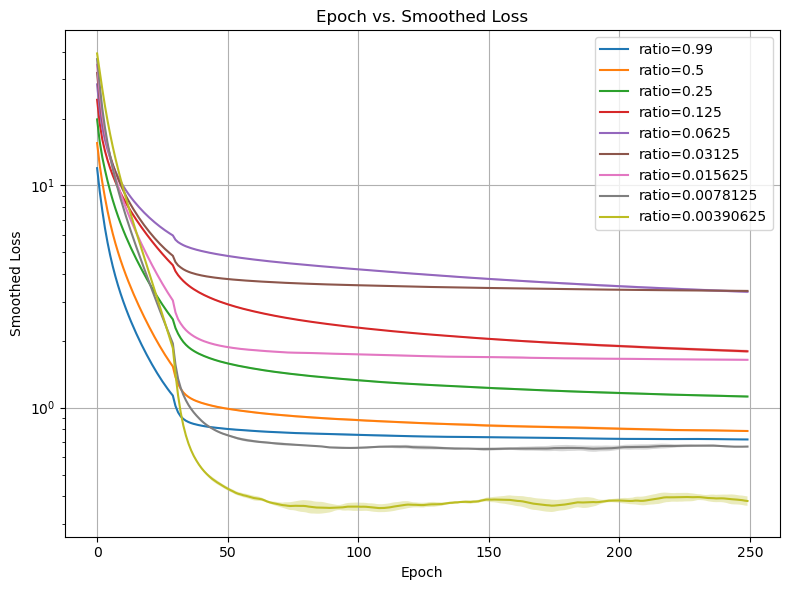

In [1]:
import os  
import re  
import math  
import matplotlib.pyplot as plt  
import numpy as np  
from scipy.optimize import curve_fit  

def parse_log(log_file):  
    """  
    解析日志文件，返回列表 [(epoch, total_loss), ...]  
    仅匹配形如：  
    132 cuda:0 0.2844359576702118 0.298878937959671 0.060276...  
    """  
    pattern = r'^(\d+)\s+([\d\.Ee\+\-]+)'  
    results = []  
    if not os.path.exists(log_file):  
        return results  
    with open(log_file, 'r') as f:  
        for line in f:  
            match = re.match(pattern, line.strip())  
            if match:  
                epoch = int(match.group(1))  
                total_loss = float(match.group(2))  
                results.append((epoch, total_loss))  
    return results  

def smooth_losses(losses, window=10):  
    """  
    对损失序列进行高斯平滑  
    losses: [l1, l2, l3, ...]  
    返回一个等长列表 [s1, s2, s3, ...]  
    使用窗口 window 和高斯权重进行平滑，权重计算公式：exp(-((i-j)^2) / (2*sigma^2))  
    其中 sigma 取 window/2.0  
    """  
    smoothed = []  
    sigma = window / 2.0  
    two_sigma_sq = 2 * sigma * sigma  
    for i in range(len(losses)):  
        start = max(0, i - window + 1)  
        window_vals = losses[start:i+1]  
        weights = []  
        for j in range(start, i+1):  
            weight = math.exp(-((i - j) ** 2) / two_sigma_sq)  
            weights.append(weight)  
        weighted_sum = sum(val * w for val, w in zip(window_vals, weights))  
        smoothed.append(weighted_sum / sum(weights))  
    return smoothed  

def find_converged_epoch(losses, thr=0.01):  
    """  
    根据新定义判定收敛:  
    - 选定某个 epoch e  
    - 若此后所有 epoch (i > e) 的 loss 相对于 losses[e] 的下降比例 <= thr，  
      即 losses[i] >= losses[e]*(1 - thr)，则判定 e 为收敛。  
    - 返回找到的最早 epoch (若没有则返回 None)  
    注意：如果后续 loss 有上升，也能满足条件（下降为负值），  
         我们只需检查不出现大于 thr 的下降即可。  
    """  
    for e in range(len(losses)):  
        base_loss = losses[e]  
        is_converged = True  
        for i in range(e+1, len(losses)):  
            relative_drop = (base_loss - losses[i]) / base_loss  # 若loss上升，relative_drop为负  
            if relative_drop > thr:  
                is_converged = False  
                break  
        if is_converged:  
            return e + 1  # 返回真实的epoch值（假定epoch从1计数）  
    return None  

def complex_sublog_fit(x, y):  
    """  
    对正数据 x 和 y 进行拟合，模型为：  
      y = a * log(b * log(c*x + d) + e) + f  
      
    参数：  
      x: array_like，自变量数据（确保 c*x+d的结果全部大于1，使内部log有效）  
      y: array_like，因变量数据  
      
    返回：  
      popt: 拟合参数 [a, b, c, d, e, f]  
      fit_fn: 拟合函数，可用于计算给定 x 下预测的 y 值  
    """  
    def model(x, a, b, c, d, e, f):  
        return a * np.log(b * np.log(c * x + d) + e) + f  
    
    x = np.array(x)  
    y = np.array(y)  
    
    # 初始猜测参数，根据数据特点可能需要调整  
    # a, b, c, d, e, f  
    initial_guess = [1.0, 1.0, 1e-5, 1.0, 1.0, 0.0]  
    
    popt, pcov = curve_fit(model, x, y, p0=initial_guess)  
    a, b, c, d, e, f_val = popt  

    def fit_fn(x_data):  
        return model(np.array(x_data), a, b, c, d, e, f_val)  
    
    return popt, fit_fn  

def main():  
    ratios = [0.99, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625]
    # ratio -> num(ratio)  
    ratio_to_num = {  
        0.99: 81244,  
        0.5: 77133,  
        0.25: 70978,  
        0.125: 62296,  
        0.0625: 51541,  
        0.03125: 39618,  
        0.015625: 27660,  
        0.0078125: 17746,
        0.00390625: 10614,
    }  

    # 使用一个或多个阈值，这里只用一个阈值  
    thresholds = [0.005]  
    
    home_path = "."  
    
    # 用于记录收敛 epoch 数据，格式：convergence_data[thr] = [ (num(ratio), avg_convergence, std_convergence), ... ]  
    convergence_data = {thr: [] for thr in thresholds}  

    # 用于记录各 ratio 下的 平均平滑 loss 曲线和标准差，格式：  
    # ratio_loss_curves[ratio] = (epochs, mean_curve, std_curve)  
    ratio_loss_curves = {}  

    for ratio in ratios:  
        all_runs_smoothed_losses = []  # 每个 turn 的平滑 loss 序列  
        run_convergence_epochs = {thr: [] for thr in thresholds}  # 每个 turn 的收敛 epoch  

        for turn in [1, 2, 3, 4, 5]:  
            # 修改后的 run_name, 包含 turn  
            log_file = f"./scaling_r{ratio}_s{turn}.log" 
            
            ep_loss_pairs = parse_log(log_file)  
            print(f"Parsed {len(ep_loss_pairs)} epoch-loss pairs from {log_file}")
            if not ep_loss_pairs:  
                continue  

            # 按 epoch 排序，并只取前 160 个  
            ep_loss_pairs.sort(key=lambda x: x[0])  
            epochs = [p[0] for p in ep_loss_pairs]
            losses = [p[1] for p in ep_loss_pairs]
            
            smoothed_losses = smooth_losses(losses, window=30)  
            all_runs_smoothed_losses.append(smoothed_losses)  
            
            # 对每个阈值，计算该 turn 的收敛 epoch  
            for thr in thresholds:  
                c_ep = find_converged_epoch(smoothed_losses, thr=thr)  
                if c_ep is None:  
                    c_ep = float('inf')  
                run_convergence_epochs[thr].append(c_ep)  
        
        if all_runs_smoothed_losses:  
            arr = np.array(all_runs_smoothed_losses)  # shape：(turn数, epoch数量)  
            mean_curve = np.mean(arr, axis=0)  
            std_curve = np.std(arr, axis=0)  
            # 保存平滑 loss 曲线的数据  
            ratio_loss_curves[ratio] = (epochs, mean_curve, std_curve)  
            
            # 对每个阈值，记录当前 ratio 的收敛 epoch 数据（取均值和标准差）  
            for thr in thresholds:  
                avg_convergence = np.mean(run_convergence_epochs[thr])  
                std_convergence = np.std(run_convergence_epochs[thr])  
                convergence_data[thr].append((ratio_to_num[ratio], avg_convergence, std_convergence))  
    
    # ---------- 图1：x=num(ratio), y=收敛 epoch（带误差条） ----------  
    plt.figure(figsize=(6, 4))  
    for thr, pts in convergence_data.items():  
        pts_sorted = sorted(pts, key=lambda x: x[0])  
        x_vals = [x for (x, _, _) in pts_sorted]  
        y_vals = [y for (_, y, _) in pts_sorted]  
        print(x_vals, y_vals)
        y_errs = [std for (_, _, std) in pts_sorted]  
        plt.errorbar(x_vals, y_vals, yerr=y_errs, fmt='-o', capsize=5, label=f"thr={thr}")  
    
    print("x_vals:", x_vals)
    print("y_vals:", y_vals)

    popt, fit_fn = complex_sublog_fit(x_vals, y_vals)
    print(f"系数：{popt}")  # 打印拟合参数
    plt.plot(x_vals, fit_fn(x_vals), 'r--', label='Fitted Curve')  # 绘制拟合曲线   
    
    plt.xlabel("num(ratio)")  
    plt.xscale("log")  
    plt.ylabel("Converged Epoch")  
    plt.title("Converged Epoch vs. num(ratio)")  
    plt.legend()  
    plt.grid(True)  
    plt.tight_layout()  
    plt.show()  

    # ---------- 图2：epoch vs. Smoothed Loss (均值曲线及标准差填充) ----------  
    plt.figure(figsize=(8, 6))  
    for ratio, (eps, mean_curve, std_curve) in ratio_loss_curves.items():  
        plt.plot(eps, mean_curve, label=f"ratio={ratio}")  
        plt.fill_between(eps, mean_curve - std_curve, mean_curve + std_curve, alpha=0.3)  
    plt.xlabel("Epoch")  
    plt.ylabel("Smoothed Loss")  
    plt.yscale("log")  
    plt.title("Epoch vs. Smoothed Loss")  
    plt.legend()  
    plt.grid(True)  
    plt.tight_layout()  
    plt.show()  

if __name__ == "__main__":  
    main()  

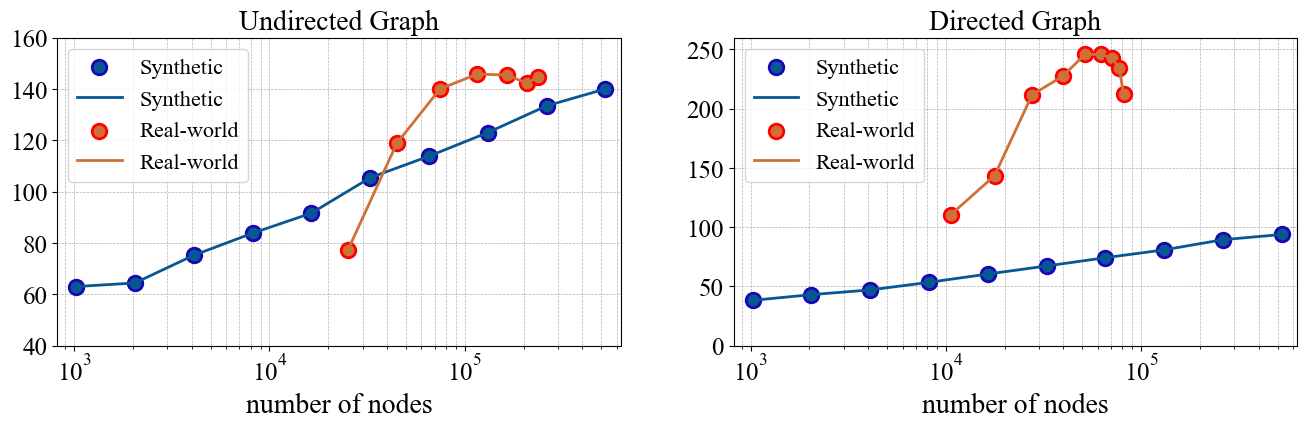

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ================== 手动输入区域 ==================

# ---- undirected synthetic ----
undir_syn_num = [2 ** 10, 2 ** 11, 2 ** 12, 2 ** 13, 2 ** 14, 2 ** 15, 2 ** 16, 2 ** 17, 2 ** 18, 2 ** 19]
undir_syn_values = [63, 64.4, 75.2, 83.8, 91.6, 105.4, 113.8, 123, 133.4, 140]

# ---- undirected real-world ----
undir_real_num = [25204, 44837, 74651, 115808, 163612, 208606, 235868]
undir_real_values = [77.2, 118.8, 140.0, 145.8, 145.4, 142.2, 144.75]

# ---- directed synthetic ----
dir_syn_num = [2 ** 10, 2 ** 11, 2 ** 12, 2 ** 13, 2 ** 14, 2 ** 15, 2 ** 16, 2 ** 17, 2 ** 18, 2 ** 19]
dir_syn_values = [38.2, 43.0, 47.0, 53.4, 60.4, 67.2, 74.2, 80.8, 89.4, 93.8]

# ---- directed real-world ----
dir_real_num = [10614, 17746, 27660, 39618, 51541, 62296, 70978, 77133, 81244]
dir_real_values = [110.6, 143.4, 211.8, 227.4, 245.8, 245.8, 242.4, 234.6, 212.0]


# ================== 拟合函数接口 ==================

def fit_undir_syn(x):
    log_x = np.log(x)
    coeff = np.polyfit(log_x, undir_syn_values, 1)
    poly = np.poly1d(coeff)
    return poly(log_x)

def fit_undir_real(x):
    return 20.97 * np.log(22.07 * np.log((7.02 * (10 ** -4)) * x + -5.54) - 53.10) + 62.04

def fit_dir_syn(x):
    return np.zeros_like(x)  # placeholder

def fit_dir_real(x):
    return np.zeros_like(x)  # placeholder


# ================== 绘图参数保持你原规范 ==================

plt.rcParams["font.family"] = "Times New Roman"
synthetic_color = "#075793"
synthetic_edge = "#1807B5"
real_color = "#CE7037"
real_edge = "red"

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
# fig.subplots_adjust(wspace=0.5)

def plot_scaling(ax, x_syn, y_syn, fit_syn, x_real, y_real, fit_real, title, ylim):
    # synthetic
    if x_syn:
        x_arr = np.array(x_syn)
        # fit_x = np.linspace(min(x_arr), max(x_arr), 200)
        # fit_y = fit_syn(fit_x)
        # ax.plot(fit_x, fit_y, color=synthetic_color, linewidth=3, linestyle='--', zorder=2)
        ax.scatter(x_arr, y_syn, color=synthetic_color, edgecolors=synthetic_edge,
                   linewidth=2, s=110, zorder=3, label='Synthetic')
        ax.plot(x_arr, y_syn, color=synthetic_color,
                   linewidth=2, zorder=3, label='Synthetic')

    # real-world
    if x_real:
        x_arr = np.array(x_real)
        # fit_x = np.linspace(min(x_arr), max(x_arr), 200)
        # fit_y = fit_real(fit_x)
        # ax.plot(fit_x, fit_y, color=real_color, linewidth=3, linestyle='--', zorder=2)
        ax.scatter(x_arr, y_real, color=real_color, edgecolors=real_edge,
                   linewidth=2, s=110, zorder=3, label='Real-world')
        ax.plot(x_arr, y_real, color=real_color,
                   linewidth=2, zorder=3, label='Real-world')

    ax.set_xscale("log")
    ax.set_xlabel("number of nodes", fontsize=20)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=18)
    ax.set_xlim(0.8 * min(x_syn + x_real), 1.2 * max(x_syn + x_real))
    ax.set_title(title, fontsize=20)
    ax.legend(fontsize=16)
    ax.set_ylim(ylim)


# ================== 绘图 ==================

plot_scaling(
    ax=axes[0],
    x_syn=undir_syn_num,
    y_syn=undir_syn_values,
    fit_syn=fit_undir_syn,
    x_real=undir_real_num,
    y_real=undir_real_values,
    fit_real=fit_undir_real,
    title="Undirected Graph",
    ylim=[40, 160]
)

plot_scaling(
    ax=axes[1],
    x_syn=dir_syn_num,
    y_syn=dir_syn_values,
    fit_syn=fit_dir_syn,
    x_real=dir_real_num,
    y_real=dir_real_values,
    fit_real=fit_dir_real,
    title="Directed Graph",
    ylim=[0, 260]
)


plt.savefig("scalability_dual.pdf", bbox_inches="tight")
plt.show()
